In [1]:
import numpy as np
from numpy import linalg as LA
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import scipy

from scipy import linalg
from scipy import stats
from pylab import * 
%matplotlib inline
from scipy.optimize import curve_fit

In [2]:
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
%matplotlib inline
import numpy as np
from numpy import linalg as LA
from scipy import linalg
from scipy import stats
from pylab import * 
#from tempfile import TemporaryFile
P = open("/cueva/Susana/Susana_josePC/Prices.txt","rb")
S = open("/cueva/Susana/Susana_josePC/Symbols.txt","r")
D = open("/cueva/Susana/Susana_josePC/Dates.txt","r")
G = open("/cueva/Susana/Susana_josePC/Gics.txt","r")
from __future__ import division 

In [3]:
s=[]
lines=S.readlines()
S.close()
for line in lines:
	values = line.split()
	s.append(values[0])
lensymbols=len(s)

d=[]
lines=D.readlines()
D.close() 
for line in lines:
	values = line.split()
	d.append(values[0])
#print type(values)	
lendates=len(d)

g=[]
lines=G.readlines()
G.close()
for line in lines:
	values = line.split()
	g.append(values[0])
    
Prices=np.loadtxt("Prices.txt")      
lenPrices=len(Prices)

In [4]:
a=np.array((2,3))
a

array([2, 3])

In [5]:
#----- Rendimientos---

Returns=[]

for i in range(lensymbols):
	Returns.append([])
	for j in range(1,lendates):
		r=(Prices[i][j-1]/Prices[i][j])-1
                Returns[-1].append(r)
Returns=np.asarray(Returns)
#print len(Returns)

In [6]:
Cmean=[]
Cmean2=[]
for i in range(262):
    #fecha=d[i]
    C=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorr%d.dat"%i)
    #CP=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorrPM%dq1.10.dat"%i)
    cm=(C.sum())-N
    cm=cm/(N**2-N)
    Cmean.append(cm)
    
    cpm=C.mean()
    Cmean2.append(cpm)


NameError: name 'N' is not defined

In [ ]:
Cmenos=[]
for i in xrange(len(Cmean)):
    Cmenos.append( Cmean[i]-Cmean2[i])

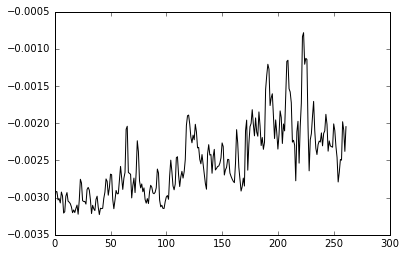

In [36]:
plt.plot(Cmenos, "black")
#plt.plot(Cmean2, "red")

In [7]:
def map_level(f, item, level):
    if level == 0:
        return f(item)
    else:
        return [map_level(f, i, level - 1) for i in item]

In [8]:
np.random.seed(9)

In [9]:
nummat=2000
N=293
T=44
e=.05
q=1+e 
numVentana=262
#corr1=0.6
#corr2=0.1
#k1=100
#k2=N-k1
q1=q+1
C = np.empty((N,N))	
Cdiag = np.empty((N,N))
Cq = np.empty((N,N))
Corr = np.empty((N,N))
Corrsqr = np.empty((N,N))
CWOEvalores=np.empty((numVentana,N))

#vtotal=np.zeros(((nummat,N,N)))   
v1total=np.empty(((nummat,N,N)))   
w1total=np.empty((nummat,N))


In [47]:
len(Returns)

293

In [10]:
###  matriz de Xi corr ###


corr1=Cmean[1]

k1=N
for i in xrange(k1):
    for j in xrange(i,k1):
        if i==j:
            Corr[i][j]=1
        else:
            Corr[i][j]=corr1
            Corr[j][i]=Corr[i][j]

Corrsqr=np.real(scipy.linalg.sqrtm(Corr))

IndexError: list index out of range

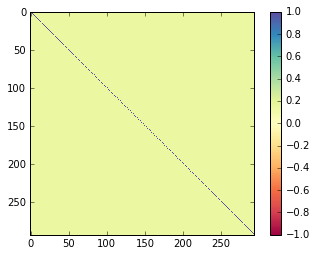

In [49]:
#plt.imshow(Corr,interpolation='nearest',cmap=plt.get_cmap('rainbow'))
#plt.colorbar()
im=plt.imshow(Corr,interpolation='nearest',cmap=plt.get_cmap("Spectral"))
plt.colorbar()
im.set_clim(-1.0, 1.0)

In [50]:
for ii in xrange(numVentana):    
    k1=N

    corr1=Cmean[ii]
    Wmean=[]
    #k3=N-k1-k2
    for i in xrange(k1):
           for j in xrange(i,k1):
               if i==j:
                   Corr[i][j]=1
               else:
                   Corr[i][j]=corr1
                   Corr[j][i]=Corr[i][j]

    Corrsqr=np.real(scipy.linalg.sqrtm(Corr))
    for matriz in xrange(nummat):
        #### matriz wishart ####

        M1 = 1 * np.random.randn(N, T) + 0	
        #print M1


        ####### normalizando el renglon ######
        #M1=[(s-s.mean())/s.std() for s in M1]
        #M1=np.asarray(M1)

        ###### transpuesta #####
        #M2=np.transpose(M1)        


        ##### haciendo la matriz de corr(wishart correlacionado) ######
        #Corrsqr=np.real(scipy.linalg.sqrtm(Corr))

        CorrsqrM1=np.dot(Corrsqr,M1)

        ###normalizando XiM1

        CorrsqrM1=[(s-s.mean())/s.std() for s in CorrsqrM1]
        CorrsqrM1=np.asarray(CorrsqrM1)
        #######

        M2Corrsqr=np.transpose(CorrsqrM1)


        C=np.dot(CorrsqrM1,M2Corrsqr)
        C=C/T
        ###### diagonalizando C #########
        #w, v = LA.eigh(C)
        #W=w

        #vtotal[matriz]=v
        ##### power mapping #####

        Cq=map_level(lambda x: abs(x)**(q1)/x, C, 2)
        Cq=np.asarray(Cq)
        ### diagonalizando Cq ###

        w1, v1 = LA.eigh(Cq)
        
        w1total[matriz]=w1 
        v1total[matriz]=v1
    for jj in xrange(N):
        Wmean.append(w1total[:,jj].mean())
    Wmean=np.asarray(Wmean)
    CWOEvalores[ii]=Wmean
    #Wmean=[]

In [51]:
titulo="/cueva/Susana/SusanaDos/CWOEevalores/CWOEcte3q%.2f"%(q)
np.save(titulo,CWOEvalores)

In [11]:
nummat=2000
N=293
T=44
e=.001
q=1+e 
numVentana=1
#corr1=0.6
#corr2=0.1
#k1=100
#k2=N-k1
q1=q+1
C = np.empty((N,N))	
Cdiag = np.empty((N,N))
Cq = np.empty((N,N))
Corr = np.empty((N,N))
Corrsqr = np.empty((N,N))
WOEvalores=np.empty(N)

#vtotal=np.zeros(((nummat,N,N)))   
v1total=np.empty(((nummat,N,N)))   
w1total=np.empty((nummat,N))
#wtotal=np.empty((nummat,N))
Wmean=[]
for matriz in xrange(nummat):
        #### matriz wishart ####

        M1 = 1 * np.random.randn(N, T) + 0
        #print M1


        ####### normalizando el renglon ######
        M1=[(s-s.mean())/s.std() for s in M1]
        M1=np.asarray(M1)

        ###### transpuesta #####
        M2=np.transpose(M1)        

        C=np.dot(M1,M2)
        C=C/T
        
        ###### diagonalizando C #########
        #w, v = LA.eigh(C)        
        #wtotal[matriz]=w
        
        ##### power mapping #####

        Cq=map_level(lambda x: abs(x)**(q1)/x, C, 2)
        Cq=np.asarray(Cq)
        
        ### diagonalizando Cq ###

        w1, v1 = LA.eigh(Cq)
        
        w1total[matriz]=w1 
        v1total[matriz]=v1
for jj in xrange(N):
        Wmean.append(w1total[:,jj].mean())
Wmean=np.asarray(Wmean)
WOEvalores=Wmean

In [12]:
titulo="/cueva/Susana/SusanaDos/CWOEevalores/ensembleWOE%.2f"%(q)
np.save(titulo,w1total)

(array([ 3.,  4.,  4.,  5.,  6.,  6.,  6.,  7.,  7.,  7.,  8.,  7.,  8.,
         7.,  8.,  8.,  8.,  8.,  8.,  8.,  7.,  8.,  8.,  7.,  8.,  7.,
         7.,  7.,  7.,  6.,  6.,  6.,  6.,  5.,  5.,  4.,  4.,  4.,  3.,  2.]),
 array([ -6.26498880e-04,  -5.14759100e-04,  -4.03019320e-04,
         -2.91279540e-04,  -1.79539761e-04,  -6.77999806e-05,
          4.39397993e-05,   1.55679579e-04,   2.67419359e-04,
          3.79159139e-04,   4.90898919e-04,   6.02638699e-04,
          7.14378479e-04,   8.26118259e-04,   9.37858038e-04,
          1.04959782e-03,   1.16133760e-03,   1.27307738e-03,
          1.38481716e-03,   1.49655694e-03,   1.60829672e-03,
          1.72003650e-03,   1.83177628e-03,   1.94351606e-03,
          2.05525584e-03,   2.16699562e-03,   2.27873540e-03,
          2.39047518e-03,   2.50221496e-03,   2.61395474e-03,
          2.72569452e-03,   2.83743430e-03,   2.94917408e-03,
          3.06091386e-03,   3.17265364e-03,   3.28439342e-03,
          3.39613320e-03,   3.

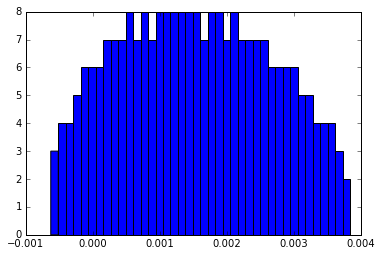

In [74]:
plt.hist(Wmean[:250],40)

In [65]:
#guardando los evalores del WOE

#fil= open("/cueva/Susana/SusanaDos/CWOEevalores/CWOEvalorq%.2f.dat"%(q),"w")
#for renglon in xrange(numVentana):
#   for item in CWOEvalores[renglon]:
#        fil.write(str(item)+" ")
#    fil.write("\n")
#fil.close
titulo="/cueva/Susana/SusanaDos/CWOEevalores/WOEq%.2f"%(q)
np.save(titulo,Wmean)

In [67]:
WW=np.load("/cueva/Susana/SusanaDos/CWOEevalores/WOEq1.05.npy")
len(WW)

293

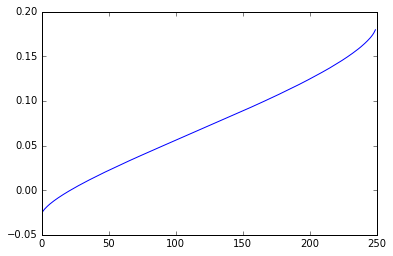

In [72]:
plt.plot(WW[:250])

In [7]:
#grafica de evalor mayor 
WWmax=[]
for i in xrange(0,262,2):
    WWmax.append(np.max(WW[i]))
plt.plot(WWmax)    

IndexError: index 2 is out of bounds for axis 0 with size 1

In [8]:
#numeros negativos
WWnega=[]
for i in xrange(0,262,2):
    suma=0
    for valor in WW[:249]:
        if valor < 1e-14:
            suma+=1
    WWnega.append(suma)
plt.plot(WWnega)    
        

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [22]:
#calculando los momentos

m1=[]
m2=[]
for i in xrange(0,262,2):
    mo1=np.mean(WW[i][:249])
    mo2=np.var(WW[i][:249])
    m1.append(mo1)
    m2.append(mo2)

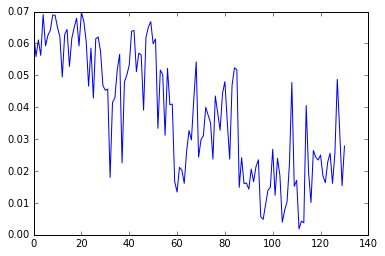

In [23]:
plt.plot(m1)

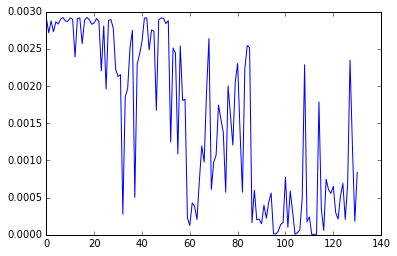

In [24]:
plt.plot(m2)

In [39]:
matriz=np.array([[[2,2,2],[2,5,1.5]],[[2,2,2],[2,2,1]]])
matriz2=[]
for jj in xrange(3):  
    matriz2.append( matriz[:,jj].mean())
matriz2    

IndexError: index 2 is out of bounds for axis 1 with size 2

In [37]:
matriz

array([[ 2. ,  2. ,  2. ],
       [ 2. ,  5. ,  1.5],
       [ 2. ,  2. ,  2. ],
       [ 2. ,  2. ,  1. ]])

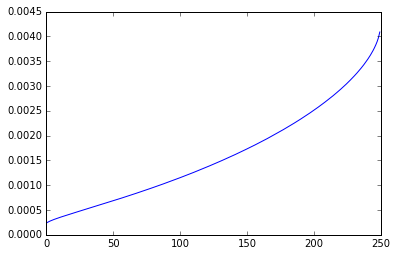

In [54]:
plt.plot(WW[223][:N-T+1])

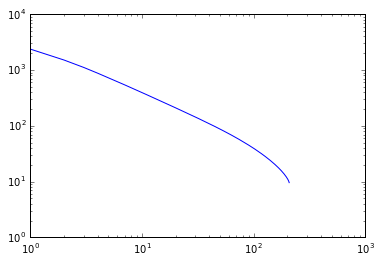

In [25]:
#zipfś law
num=np.arange(22)
e = math.exp(1)
plt.loglog(1/(WW[200][40:249]))
#num

 #evv==vtotal[2][:,250]
 #MATT=np.dot(C,evv)
 #print MATT/ev

In [43]:
WW[20][0]


-0.031544320905551967

In [40]:
#vtotal[:,:][:,N-1]==vtotal[:,N-1]

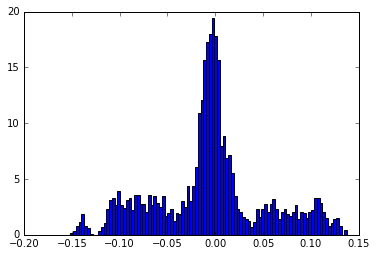

In [71]:
altura,cajas,ignorar=plt.hist((vtotal[:,:,N-1]).flatten(),100, normed=1,histtype='bar')

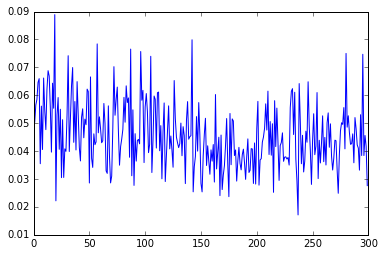

In [72]:
vtmn=(abs(vtotal[:,:,201])).mean(axis=0)
plt.plot(vtmn)

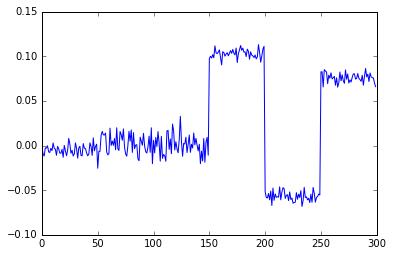

In [73]:
plt.plot(vtotal[3,:,N-1])

In [10]:
### ajustando una gaussina
Centrocajas=np.zeros(len(altura))
ds=cajas[1]-cajas[0]

#    print ds
for i in xrange(0,len(cajas)-1):
    Centrocajas[i]=cajas[i]+ds/2

#model function
def f(x, a, b,c):
    return a*np.exp(-((x-b)**2)/(2*c**2))

# Do the fit
popt, pcov = curve_fit(f, Centrocajas, altura, [1.0, 1.0,1.0])
# Plot data


# Plot fit curve
fit_x = np.linspace(-.25, .25, 200) 
#plt.plot(fit_x, f(fit_x, *popt),'r-', label="Fitted Curve")
#plt.legend()
#print popt

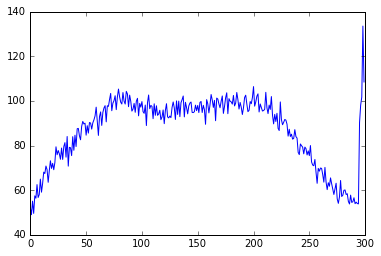

In [74]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

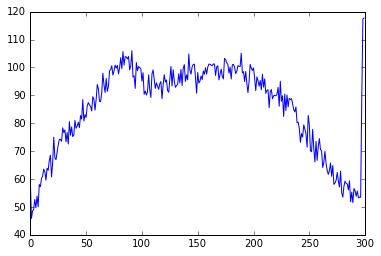

In [55]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

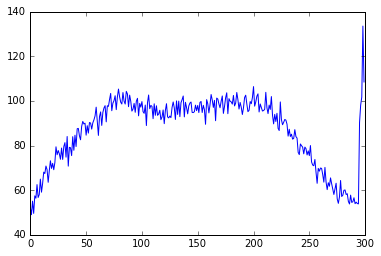

In [75]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

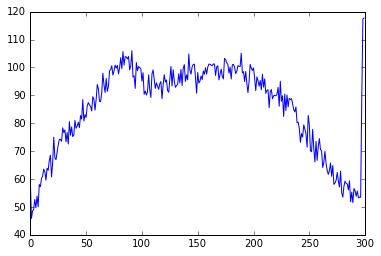

In [54]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

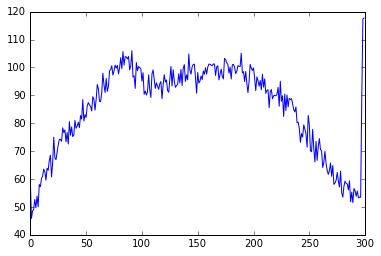

In [53]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

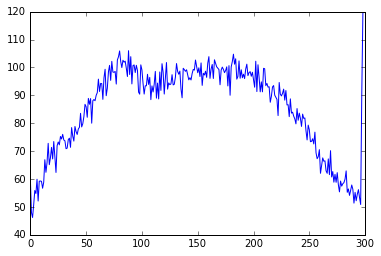

In [14]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

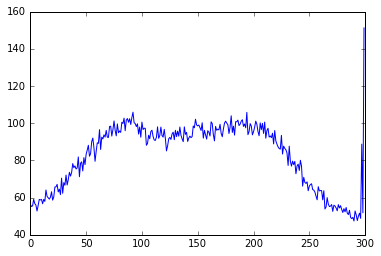

In [33]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

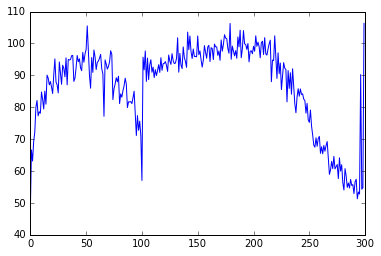

In [66]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(vtotal**4,axis=1)
vIPR=1/vIPR
plt.plot(vIPR.mean(axis=0))

In [17]:
plt.plot(vIPR[10])

IndexError: index 10 is out of bounds for axis 0 with size 10

In [18]:
sumarray=[]
for k in xrange(nummat):
    suma=[]
    for i in xrange(N):
        sumvv=0
        for j in xrange(N-T+1,N):
            v1v=np.dot(v1total[k,:,i],vtotal[k,:,j])
            sumvv+=(v1v)**2  
        suma.append(sumvv)
    sumarray.append(suma)
    
#plt.plot(sum[:])


In [11]:
sumarray=np.asarray(sumarray)
sumn=sumarray.mean(axis=0)

In [19]:
plt.semilogy(sumn[:])

NameError: name 'sumn' is not defined